## Is the NVS distribution Boltzmann for the RWA oscillators?

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial
from jax.scipy.special import logsumexp
from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [12]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# System Physical Parameters
M = 1.0                # Mass (arbitrary units)
w_0 = 10.
damping = 0.0001
Qual = w_0/(2*damping)# Natural frequency (rad/s)
print(f"Qual: {Qual}")
gamma = 500.         # Nonlinearity coefficient (Duffing term)

# Driving Forces Parameters
w_p = 2*w_0          # Parametric driving frequency (rad/s), set to 2*w_0 for parametric resonance
F_p = 5.          # Amplitude of parametric driving
F = 0.00              # Amplitude of direct driving
w_F = w_0            # Frequency of direct driving (rad/s)

# Thermal Parameters
k_B = 1.0            # Boltzmann's constant (arbitrary units)
T = .05            # Temperature (K) - currently set to 0

# Time and Simulation Parameters
period = 2*jnp.pi/w_0        # Natural period of oscillation
t0 = 0.0                     # Start time
num_periods = 1000000            # Number of periods to simulate
t1 = num_periods*period      # End time
dt0 = period/100           # Initial time step
num_pts_per_period = 100    # Number of points per period
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)



Qual: 50000.0


In [13]:
def Hamiltonian(Q, P):
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(4*M*w_p) * (P**2 - Q**2) - F*Q/(2*M*w_p)

temp_rescaling_factor = F_p/w_p
def Hamiltonian_BM(Q, P):
    return Hamiltonian(Q, P)/(k_B * T/(M*(w_0)**2))

def make_normalized_distribution(Qs, Ps):
    # Create a 2D mesh of all (x,y) points
    Qs, Ps = jnp.meshgrid(Qs, Ps)  # shape = (len(xs), len(ys))

    # Compute the log of unnormalized probabilities on the 2D grid
    log_unnorm_grid = -Hamiltonian_BM(Qs, Ps)  # shape = (len(xs), len(ys))

    # Flatten to compute log-sum-exp across all grid points
    log_unnorm_flat = log_unnorm_grid.ravel()  
    logZ = logsumexp(log_unnorm_flat)

    def BM_distribution(Q,P):
        return jnp.exp(-Hamiltonian_BM(Q, P) - logZ)

    return BM_distribution

Q_range = jnp.linspace(-5, 5, 10)/35
P_range = jnp.linspace(-5, 5, 10)/35

BM_distribution = make_normalized_distribution(Q_range,P_range)

BM_distribution_values = jax.vmap(jax.vmap(BM_distribution, in_axes=(None, 0)), in_axes=(0, None))(Q_range, P_range).T
BM_distribution_values_Q_marginal = jnp.sum(BM_distribution_values, axis=0)
BM_distribution_values_P_marginal = jnp.sum(BM_distribution_values, axis=1)
H_values = jax.vmap(jax.vmap(Hamiltonian, in_axes=(None, 0)), in_axes=(0, None))(Q_range, P_range).T

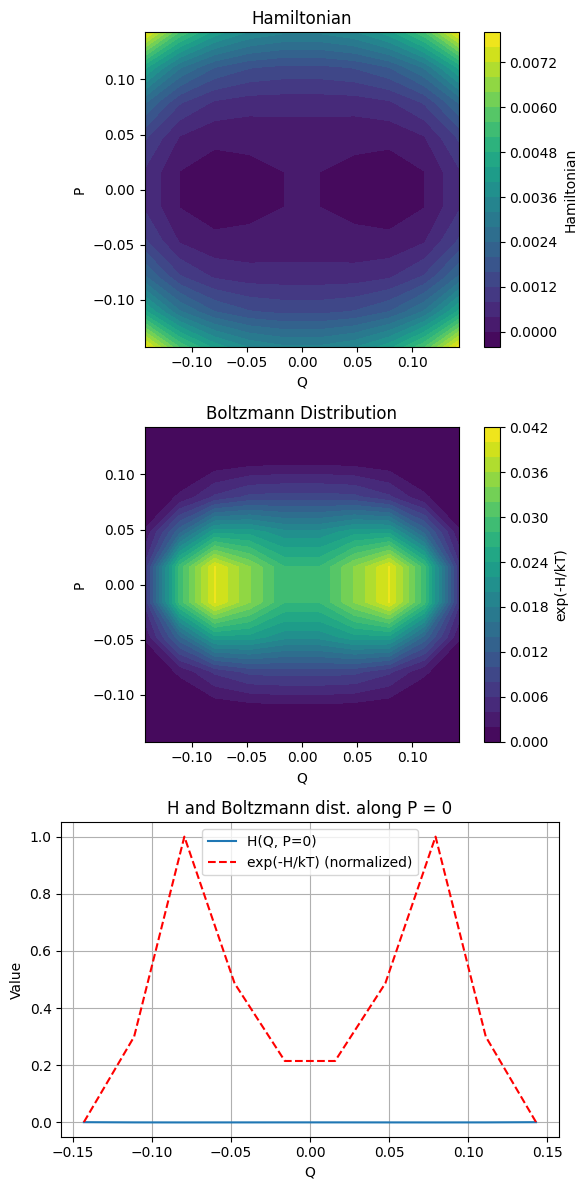

In [14]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12))

# Create Hamiltonian contour plot
contour1 = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour1, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Hamiltonian')

# Create Boltzmann distribution contour plot
contour2 = ax2.contourf(Q_range, P_range, BM_distribution_values, levels=20, cmap='viridis')
plt.colorbar(contour2, ax=ax2, label='exp(-H/kT)')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Boltzmann Distribution')

# Plot P = 0 line for both
H_P0 = jnp.array([Hamiltonian(q, 0.) for q in Q_range])
boltz_P0 = jnp.exp(-H_P0/(k_B * T*temp_rescaling_factor/(M*(w_0)**2)))

ax3.plot(Q_range, H_P0, label='H(Q, P=0)')
ax3.plot(Q_range, boltz_P0/jnp.max(boltz_P0), '--', label='exp(-H/kT) (normalized)', color='red')
ax3.set_xlabel('Q')
ax3.set_ylabel('Value')
ax3.set_title('H and Boltzmann dist. along P = 0')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

In [25]:
# # Amplitude Equations SDEs for RWA
def drift_QP_fn(t, state, args):
    """
    Drift function 
    """
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(_Q, _P)
    
    dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
    dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])

def jacobian_drift(t, state, args):
    """
    Computes the Jacobian matrix of the drift function.
    Returns a 2x2 matrix where:
    [[∂(dQ/dt)/∂Q, ∂(dQ/dt)/∂P],
     [∂(dP/dt)/∂Q, ∂(dP/dt)/∂P]]
    """
    return jax.jacfwd(lambda s: drift_QP_fn(t, s, args))(state)


def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations.
    Returns a 2x2 matrix where diagonal terms represent independent noise for Q and P.
    """
    noise_strength_QP =  jnp.sqrt(2*(w_0/(2*Qual))*k_B * T/(M*w_0**2))  
    return noise_strength_QP * jnp.eye(2) 


def G_0thOrder(t, state, args):
    return diffusion_QP_fn(t, state, args)@(jnp.eye(2)-2*(jacobian_drift(t, state, args)-jacobian_drift(t, state, args).T)) 

integrand_G_0thOrder = lambda t, state, args: -jnp.linalg.inv(G_0thOrder(t, state, args))@drift_QP_fn(t, state, args)



In [26]:
# First, let's create functions to evaluate each component of the integrand
def evaluate_integrand_Q(Q, P):
    state = jnp.array([Q, P])
    return integrand_G_0thOrder(0., state, ())[0]  # Q component

def evaluate_integrand_P(Q, P):
    state = jnp.array([Q, P])
    return integrand_G_0thOrder(0., state, ())[1]  # P component

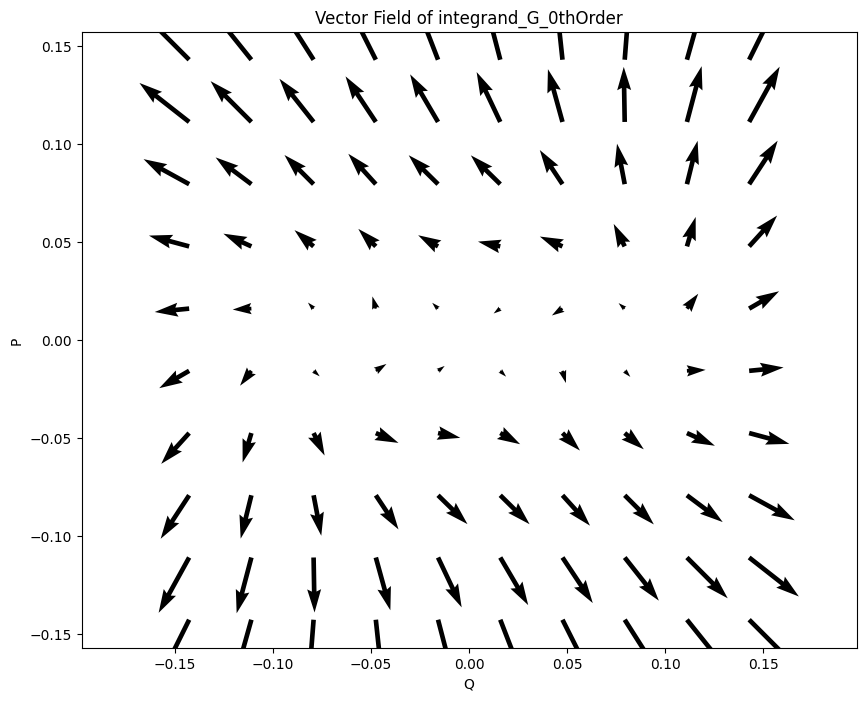

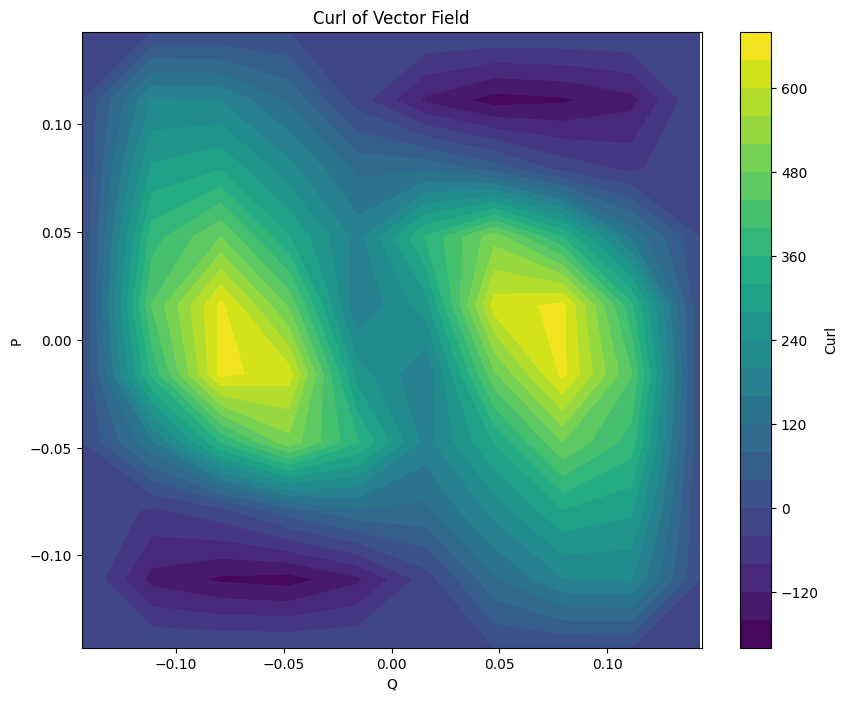

In [27]:
# Create a grid of points
Q_grid, P_grid = jnp.meshgrid(Q_range, P_range)

# Evaluate vector field components on the grid
vector_field_Q = jnp.zeros_like(Q_grid)
vector_field_P = jnp.zeros_like(P_grid)

# Evaluate point by point
for i in range(len(Q_range)):
    for j in range(len(P_range)):
        Q = Q_grid[i,j]
        P = P_grid[i,j]
        state = jnp.array([Q, P])
        result = integrand_G_0thOrder(0., state, ())
        vector_field_Q = vector_field_Q.at[i,j].set(result[0])
        vector_field_P = vector_field_P.at[i,j].set(result[1])

# Plot the vector field
plt.figure(figsize=(10, 8))
plt.quiver(Q_grid, P_grid, vector_field_Q, vector_field_P)
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Vector Field of integrand_G_0thOrder')
plt.axis('equal')
plt.show()

# Compute curl using finite differences
dQ = Q_range[1] - Q_range[0]
dP = P_range[1] - P_range[0]

# Compute derivatives using central differences
dFy_dx = jnp.zeros_like(Q_grid)
dFx_dy = jnp.zeros_like(P_grid)

# Interior points
dFy_dx = dFy_dx.at[1:-1, 1:-1].set((vector_field_P[1:-1, 2:] - vector_field_P[1:-1, :-2]) / (2 * dQ))
dFx_dy = dFx_dy.at[1:-1, 1:-1].set((vector_field_Q[2:, 1:-1] - vector_field_Q[:-2, 1:-1]) / (2 * dP))

curl_values = dFy_dx - dFx_dy

plt.figure(figsize=(10, 8))
plt.contourf(Q_grid, P_grid, curl_values, levels=20)
plt.colorbar(label='Curl')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Curl of Vector Field')
plt.axis('equal')
plt.show()



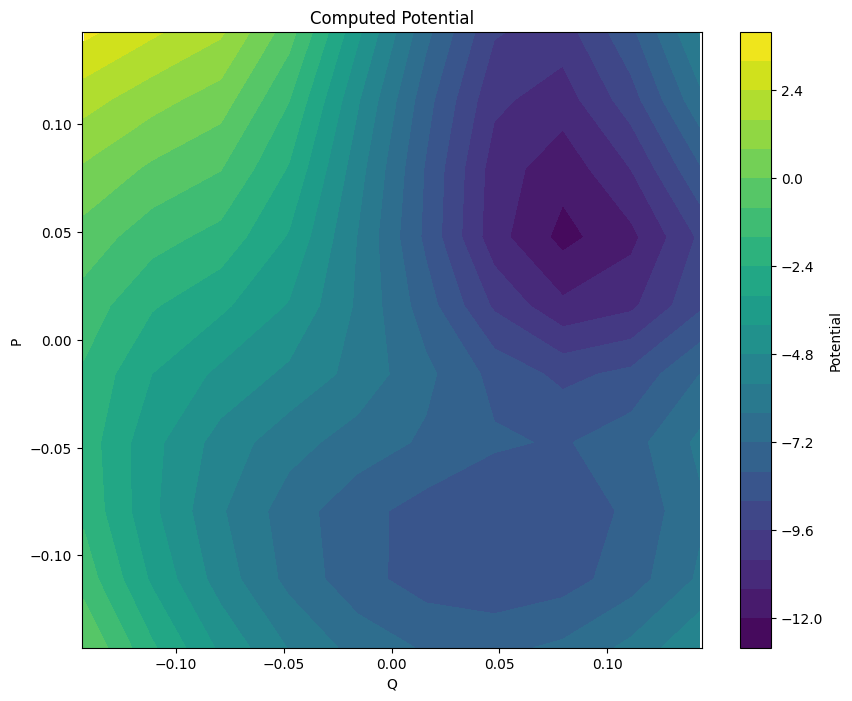

In [29]:
def compute_potential(Q_grid, P_grid):
    potential = jnp.zeros_like(Q_grid)
    
    # For each point in the grid
    for i in range(len(Q_range)):
        for j in range(len(P_range)):
            Q_target = Q_range[i]
            P_target = P_range[j]
            
            # Integrate along Q at fixed P
            Q_integral = 0.0
            for k in range(len(Q_range)-1):
                if Q_range[k] < Q_target:
                    Q_mid = (Q_range[k] + Q_range[k+1])/2
                    Q_integral += vector_field_Q[j, k] * dQ
            
            # Integrate along P at final Q
            P_integral = 0.0
            for k in range(len(P_range)-1):
                if P_range[k] < P_target:
                    P_mid = (P_range[k] + P_range[k+1])/2
                    P_integral += vector_field_P[k, i] * dP
            
            potential = potential.at[i,j].set(Q_integral + P_integral)
    
    return potential

# Compute the potential directly on the grid
potential_values = compute_potential(Q_grid, P_grid)

# Plot potential
plt.figure(figsize=(10, 8))
plt.contourf(Q_grid, P_grid, potential_values, levels=20)
plt.colorbar(label='Potential')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Computed Potential')
plt.axis('equal')
plt.show()